## **Exercise 00 : Line chart**

In [1]:
import pandas as pd
import sqlite3

# make a connection to the database (it is the same as the previous day)
# run a query that gets the datetime from the pageviews table, selecting only the users and not the admins
pd.set_option('display.max_rows', 10)
connection = sqlite3.connect('../data/checking-logs.sqlite')
visits = pd.read_sql('select datetime as date from pageviews where uid like "%user_%"', connection)
# or just: select date(datetime) AS date from pageviews where uid like '%user_%' group by date

# using Pandas, create a new dataframe where the visits are counted and grouped by date using Pandas method .plot(), create a graph
visits['date'] = pd.to_datetime(visits['date']).dt.strftime('%Y-%m-%d')
visits2 = visits.groupby('date')['date'].count()
visits2

date
2020-04-17     1
2020-04-18    23
2020-04-19    15
2020-04-21     3
2020-04-22     1
              ..
2020-05-18    51
2020-05-19    11
2020-05-20    12
2020-05-21    11
2020-05-22     2
Name: date, Length: 33, dtype: int64

<Axes: title={'center': 'Views per day'}, xlabel='date'>

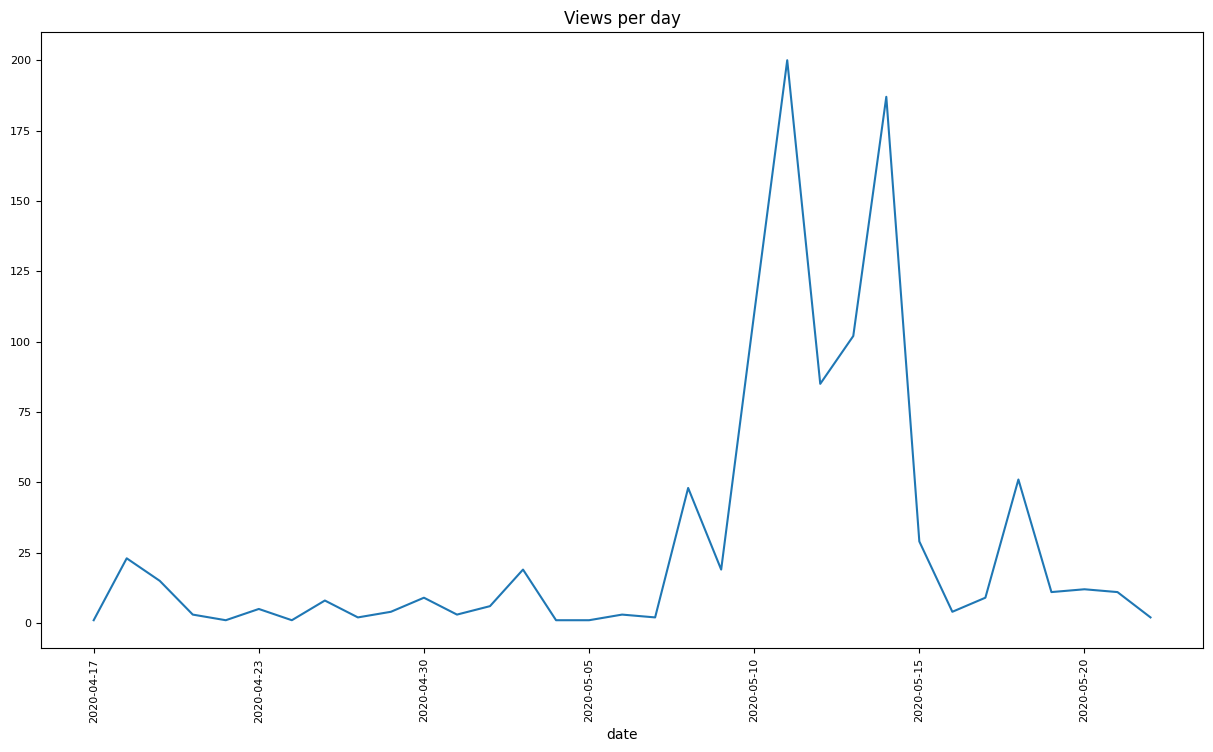

In [2]:
# the size of the font should be 8
# the size of the figure is (15,8)
# the graph must have the title Views per day
# notice the rotation of xticks on the graph below
visits2.plot(fontsize=8, figsize = (15,8), title='Views per day', rot=90)

In [3]:
# close the connection to the database
connection.close()